---
# Notebook 3 — Model Training & Experiments
### Pakistan Export Demand Forecasting System | Final Year Project

---

## Approach — Panel Regression (Option B)
The master dataset is in **long/panel format** — one row per commodity per month.  
`HS_Code` is a categorical feature that lets a single model learn a different response for each commodity.  
This is more powerful than fitting 10 separate models.

## Models Evaluated (simple → advanced)
| # | Model | HS_Code Handling |
|---|-------|------------------|
| 1 | Random Forest | OrdinalEncoder (RF needs numeric input) |
| 2 | **XGBoost** | `enable_categorical=True` ← **Champion (lowest MAPE)** |
| 3 | CatBoost | `cat_features=['HS_Code']` |
| 4 | LightGBM | `categorical_feature=['HS_Code']` |

## Train / Test Split
- **Train:** Jul 2010 – Dec 2023 → 1,620 rows
- **Test:** Jan 2024 – Dec 2025 → 240 rows
- Split is **time-based** (never random) to prevent data leakage

## Target Metrics
- **MAPE < 25%** (primary)
- **R² > 0.70**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import time
import warnings
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, r2_score

import xgboost as xgb
from catboost import CatBoostRegressor
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# Short labels for chart readability
HS_LABELS = {
    '1006': 'Rice',        '1207': 'Oil Seeds',   '2523': 'Cement',
    '5205': 'Cotton Yarn', '6110': 'Winter Wear',  '6203': 'Mens Suits',
    '6302': 'Bed Linens',  '7403': 'Copper',       '9018': 'Medical Instr.',
    '9506': 'Sports Goods'
}
COLORS = list(plt.cm.tab10.colors)

print('All libraries loaded.')
print(f'XGBoost  : {xgb.__version__}')
print(f'LightGBM : {lgb.__version__}')

All libraries loaded.
XGBoost  : 3.2.0
LightGBM : 4.6.0


---
## Section 1 — Load Data & Define Features

In [2]:
DATA_PATH = Path('..') / 'Data' / 'Master_FYP_Dataset.csv'
df = pd.read_csv(DATA_PATH, dtype={'HS_Code': str})

print(f'Dataset loaded — {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Date range : {df["Date_YYYYMM"].min()}  to  {df["Date_YYYYMM"].max()}')
df.head(3)

Dataset loaded — 1860 rows x 16 columns
Date range : 201007  to  202512


,Date_YYYYMM,HS_Code,Commodity_Name,Export_Value_USD,USD_PKR_Close,Brent_Oil_Avg,US_Consumer_Confidence,Year,Month,Month_Sin,Month_Cos,Lag_1M,Lag_3M,Lag_6M,Rolling_3M_Avg,Rolling_6M_Avg
0,201007,1006,Rice,2.177887e+08,85.199997,75.509000,67.8,2010,7,-0.500000,-8.660254e-01,2.004378e+08,1.890975e+08,2.358505e+08,1.868071e+08,2.097255e+08
1,201008,1006,Rice,1.282170e+08,84.177002,77.115000,68.9,2010,8,-0.866025,-5.000000e-01,2.177887e+08,1.708859e+08,2.060461e+08,1.963708e+08,2.067152e+08
2,201009,1006,Rice,1.271972e+08,86.150002,78.490952,68.2,2010,9,-1.000000,-1.836970e-16,1.282170e+08,2.004378e+08,2.560354e+08,1.821479e+08,1.937437e+08


In [3]:
# 13 input features — HS_Code is the key categorical identifier
FEATURE_COLS = [
    'HS_Code',
    'USD_PKR_Close', 'Brent_Oil_Avg', 'US_Consumer_Confidence',
    'Year', 'Month', 'Month_Sin', 'Month_Cos',
    'Lag_1M', 'Lag_3M', 'Lag_6M',
    'Rolling_3M_Avg', 'Rolling_6M_Avg'
]
TARGET_COL = 'Export_Value_USD'

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

print(f'Features : {len(FEATURE_COLS)}')
print(f'Target   : {TARGET_COL}')
print(f'X shape  : {X.shape}')
print(f'y shape  : {y.shape}')

Features : 13
Target   : Export_Value_USD
X shape  : (1860, 13)
y shape  : (1860,)


In [4]:
# Time-based split — NEVER use random split on time series data (causes leakage)
train_mask = df['Date_YYYYMM'] <= 202312
test_mask  = df['Date_YYYYMM'] >= 202401

X_train = X[train_mask].copy()
X_test  = X[test_mask].copy()
y_train = y[train_mask].copy()
y_test  = y[test_mask].copy()

print('Train / Test Split Summary')
print('-' * 40)
print(f'Train rows  : {len(X_train):,}  ({df.loc[train_mask, "Date_YYYYMM"].min()} to {df.loc[train_mask, "Date_YYYYMM"].max()})')
print(f'Test rows   : {len(X_test):,}   ({df.loc[test_mask, "Date_YYYYMM"].min()} to {df.loc[test_mask, "Date_YYYYMM"].max()})')
print(f'Train share : {len(X_train)/len(X)*100:.1f}%')
print(f'Test share  : {len(X_test)/len(X)*100:.1f}%')

Train / Test Split Summary
----------------------------------------
Train rows  : 1,620  (201007 to 202312)
Test rows   : 240   (202401 to 202512)
Train share : 87.1%
Test share  : 12.9%


---
## Section 2 — Preprocessing

Different models need `HS_Code` in different formats:
- **Random Forest** — needs a plain integer (OrdinalEncoder)
- **XGBoost & LightGBM** — needs Pandas `category` dtype
- **CatBoost** — handles raw strings directly, no encoding needed

In [5]:
# --- Preprocessing for Random Forest ---
# OrdinalEncoder converts each unique HS_Code string to a stable integer
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_rf = X_train.copy()
X_test_rf  = X_test.copy()

X_train_rf['HS_Code'] = oe.fit_transform(X_train[['HS_Code']]).astype(int)
X_test_rf['HS_Code']  = oe.transform(X_test[['HS_Code']]).astype(int)

print('OrdinalEncoder mapping (HS_Code string -> integer):')
for code, enc in zip(oe.categories_[0], range(len(oe.categories_[0]))):
    print(f'  {code}  ->  {enc}  ({HS_LABELS[code]})')

OrdinalEncoder mapping (HS_Code string -> integer):
  1006  ->  0  (Rice)
  1207  ->  1  (Oil Seeds)
  2523  ->  2  (Cement)
  5205  ->  3  (Cotton Yarn)
  6110  ->  4  (Winter Wear)
  6203  ->  5  (Mens Suits)
  6302  ->  6  (Bed Linens)
  7403  ->  7  (Copper)
  9018  ->  8  (Medical Instr.)
  9506  ->  9  (Sports Goods)


In [6]:
# --- Preprocessing for XGBoost and LightGBM ---
# Pandas category dtype signals to these models that HS_Code is categorical
# Fit categories on train to ensure consistent encoding across train and test
hs_categories = sorted(X_train['HS_Code'].unique())

X_train_gb = X_train.copy()
X_test_gb  = X_test.copy()

X_train_gb['HS_Code'] = pd.Categorical(X_train_gb['HS_Code'], categories=hs_categories)
X_test_gb['HS_Code']  = pd.Categorical(X_test_gb['HS_Code'],  categories=hs_categories)

# CatBoost uses original string X_train / X_test directly — no conversion needed

print('Gradient boosting preprocessing done.')
print(f'HS_Code dtype in X_train_gb : {X_train_gb["HS_Code"].dtype}')
print(f'Categories : {hs_categories}')

Gradient boosting preprocessing done.
HS_Code dtype in X_train_gb : category
Categories : ['1006', '1207', '2523', '5205', '6110', '6203', '6302', '7403', '9018', '9506']


---
## Section 3 — Evaluation Helper Functions

**Safe MAPE:** Standard MAPE divides by the actual value. If any Copper months have `Export_Value_USD = 0` (zero-filled no-trade months), this causes division by zero. The safe version skips those rows.

In [7]:
def safe_mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    # Skip rows where actual = 0 to avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate(model_name, y_true, y_pred):
    mape = safe_mape(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    goal_mape = 'YES' if mape < 25 else 'NO'
    goal_r2   = 'YES' if r2   > 0.70 else 'NO'
    print(f'  MAPE  : {mape:.2f}%   [Target < 25% : {goal_mape}]')
    print(f'  RMSE  : ${rmse/1e6:.2f}M')
    print(f'  R²    : {r2:.4f}  [Target > 0.70 : {goal_r2}]')
    return {'Model': model_name, 'MAPE_%': round(mape, 2),
            'RMSE_M': round(rmse / 1e6, 2), 'R2': round(r2, 4)}


# All model results are collected here for the final comparison table
results = []

print('Evaluation functions ready.')

Evaluation functions ready.


---
## Section 4 — Model 1: Random Forest (Advanced Baseline)

Random Forest is our starting benchmark. It is an ensemble of decision trees that averages predictions to reduce variance. It cannot natively handle categorical strings, so `HS_Code` is ordinally encoded before training.

In [8]:
print('Training Random Forest ...')

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,      # let trees grow fully
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

t0 = time.time()
rf_model.fit(X_train_rf, y_train)
rf_time = time.time() - t0

print(f'Done.  Training time : {rf_time:.1f}s')

Training Random Forest ...
Done.  Training time : 0.3s


In [9]:
rf_preds = rf_model.predict(X_test_rf)

print('--- Random Forest ---')
results.append(evaluate('Random Forest', y_test, rf_preds))

--- Random Forest ---
  MAPE  : 21.18%   [Target < 25% : YES]
  RMSE  : $26.57M
  R²    : 0.9560  [Target > 0.70 : YES]


---
## Section 5 — Model 2: XGBoost

XGBoost builds trees sequentially — each tree corrects the errors of the previous one. With `enable_categorical=True` and the `hist` tree method, it handles `HS_Code` natively without manual encoding.

In [10]:
print('Training XGBoost ...')

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    tree_method='hist',   # required for categorical support
    random_state=42,
    verbosity=0
)

t0 = time.time()
xgb_model.fit(X_train_gb, y_train)
xgb_time = time.time() - t0

print(f'Done.  Training time : {xgb_time:.1f}s')

Training XGBoost ...
Done.  Training time : 0.4s


In [11]:
xgb_preds = xgb_model.predict(X_test_gb)

print('--- XGBoost ---')
results.append(evaluate('XGBoost', y_test, xgb_preds))

--- XGBoost ---
  MAPE  : 20.41%   [Target < 25% : YES]
  RMSE  : $28.83M
  R²    : 0.9482  [Target > 0.70 : YES]


---
## Section 6 — Model 3: CatBoost

CatBoost was specifically designed for datasets with categorical features. It applies ordered target statistics to encode categoricals internally — no manual encoding needed. It passes raw `HS_Code` strings directly via `cat_features`.

In [12]:
print('Training CatBoost ...')

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0            # suppress all training output
)

t0 = time.time()
# Pass raw string HS_Code directly — CatBoost handles it natively
cat_model.fit(X_train, y_train, cat_features=['HS_Code'])
cat_time = time.time() - t0

print(f'Done.  Training time : {cat_time:.1f}s')

Training CatBoost ...
Done.  Training time : 8.5s


In [13]:
cat_preds = cat_model.predict(X_test)

print('--- CatBoost ---')
results.append(evaluate('CatBoost', y_test, cat_preds))

--- CatBoost ---
  MAPE  : 26.76%   [Target < 25% : NO]
  RMSE  : $27.91M
  R²    : 0.9514  [Target > 0.70 : YES]


---
## Section 7 — Model 4: LightGBM

LightGBM grows trees **leaf-wise** (not level-wise) — it focuses compute on the most impactful splits, making it faster and more accurate on tabular data. Its native categorical support with panel data makes it well-suited for this problem.

Key hyperparameters:
- `num_leaves=63` — controls tree complexity (default 31 is too conservative here)
- `subsample + colsample_bytree` — row and column sampling to prevent overfitting
- `min_child_samples=20` — minimum rows per leaf to keep predictions stable

In [14]:
print('Training LightGBM ...')

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,         # no depth limit — let num_leaves control complexity
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    n_jobs=-1,
    random_state=42,
    verbose=-1            # suppress all training logs
)

t0 = time.time()
lgb_model.fit(
    X_train_gb, y_train,
    categorical_feature=['HS_Code']
)
lgb_time = time.time() - t0

print(f'Done.  Training time : {lgb_time:.1f}s')

Training LightGBM ...
Done.  Training time : 0.5s


In [15]:
lgb_preds = lgb_model.predict(X_test_gb)

print('--- LightGBM ---')
results.append(evaluate('LightGBM', y_test, lgb_preds))

--- LightGBM ---
  MAPE  : 28.02%   [Target < 25% : NO]
  RMSE  : $29.47M
  R²    : 0.9459  [Target > 0.70 : YES]


---
## Section 8 — Model Comparison

Compare all four models on the test set across all three metrics.

In [16]:
results_df = pd.DataFrame(results)

# Mark the best value in each column
print('Model Comparison — Test Set (Jan 2024 – Dec 2025)')
print('=' * 55)
print(results_df.to_string(index=False))
print()
print(f'Champion (lowest MAPE)  : {results_df.loc[results_df["MAPE_%"].idxmin(), "Model"]}')
print(f'Champion (highest R²)   : {results_df.loc[results_df["R2"].idxmax(), "Model"]}')

Model Comparison — Test Set (Jan 2024 – Dec 2025)
        Model  MAPE_%  RMSE_M     R2
Random Forest   21.18   26.57 0.9560
      XGBoost   20.41   28.83 0.9482
     CatBoost   26.76   27.91 0.9514
     LightGBM   28.02   29.47 0.9459

Champion (lowest MAPE)  : XGBoost
Champion (highest R²)   : Random Forest


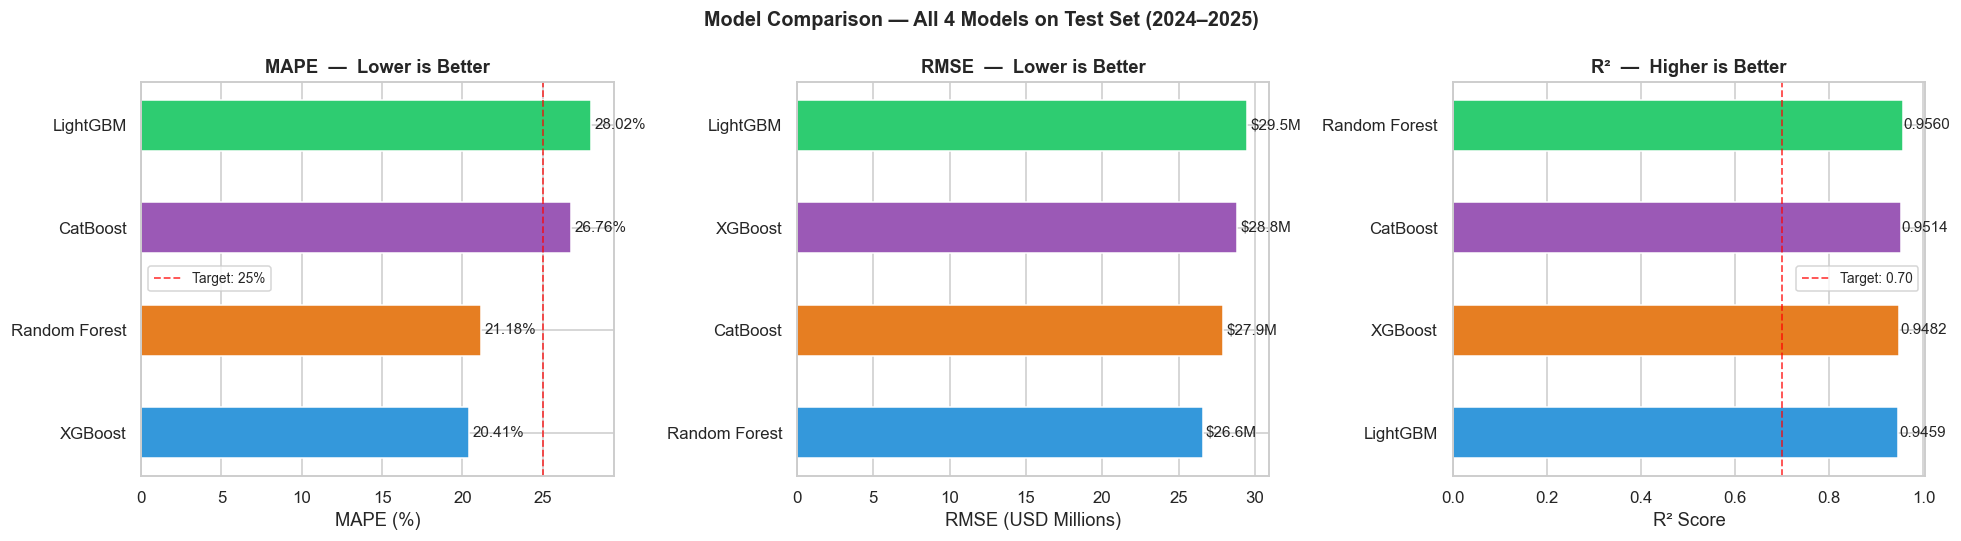

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_colors = ['#3498db', '#e67e22', '#9b59b6', '#2ecc71']

# --- MAPE (lower is better) ---
df_mape = results_df.sort_values('MAPE_%')
bars = axes[0].barh(df_mape['Model'], df_mape['MAPE_%'],
                    color=model_colors, edgecolor='white', height=0.5)
axes[0].axvline(25, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Target: 25%')
axes[0].set_xlabel('MAPE (%)')
axes[0].set_title('MAPE  —  Lower is Better', fontweight='bold')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, df_mape['MAPE_%'].values):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=10)

# --- RMSE (lower is better) ---
df_rmse = results_df.sort_values('RMSE_M')
bars2 = axes[1].barh(df_rmse['Model'], df_rmse['RMSE_M'],
                     color=model_colors, edgecolor='white', height=0.5)
axes[1].set_xlabel('RMSE (USD Millions)')
axes[1].set_title('RMSE  —  Lower is Better', fontweight='bold')
for bar, val in zip(bars2, df_rmse['RMSE_M'].values):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'${val:.1f}M', va='center', fontsize=10)

# --- R² (higher is better) ---
df_r2 = results_df.sort_values('R2', ascending=True)
bars3 = axes[2].barh(df_r2['Model'], df_r2['R2'],
                     color=model_colors, edgecolor='white', height=0.5)
axes[2].axvline(0.70, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Target: 0.70')
axes[2].set_xlabel('R² Score')
axes[2].set_title('R²  —  Higher is Better', fontweight='bold')
axes[2].legend(fontsize=9)
for bar, val in zip(bars3, df_r2['R2'].values):
    axes[2].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10)

plt.suptitle('Model Comparison — All 4 Models on Test Set (2024–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 9 — Feature Importance (XGBoost Champion)

XGBoost tracks how much each feature contributes to reducing prediction error across all trees.  
Higher importance = more splits on that feature = stronger influence on predictions.

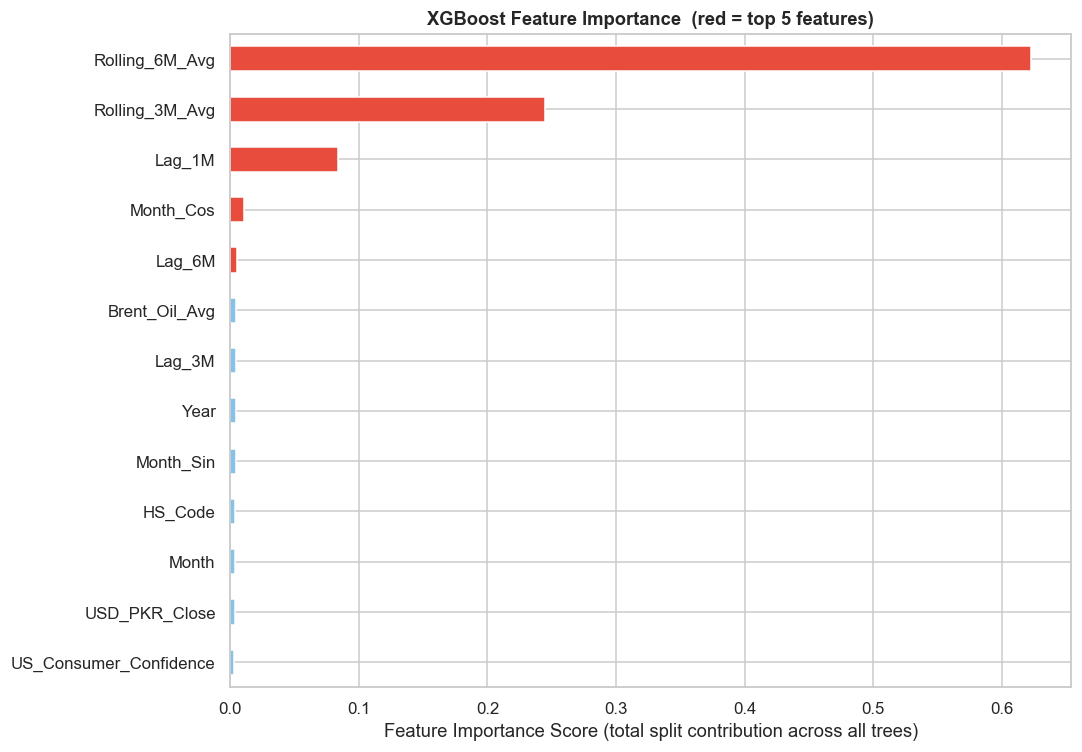

Top 5 most important features:
  1. Rolling_6M_Avg        importance = 0.6229
  2. Rolling_3M_Avg        importance = 0.2451
  3. Lag_1M                importance = 0.0838
  4. Month_Cos             importance = 0.0107
  5. Lag_6M                importance = 0.0052


In [18]:
# Extract feature importances from the trained XGBoost model
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

# Color top-5 features differently to highlight them
threshold = feat_imp.nlargest(5).min()
bar_colors = ['#e74c3c' if v >= threshold else '#85c1e9' for v in feat_imp.values]

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.set_xlabel('Feature Importance Score (total split contribution across all trees)')
ax.set_title('XGBoost Feature Importance  (red = top 5 features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
for rank, (feat, val) in enumerate(feat_imp.sort_values(ascending=False).head(5).items(), 1):
    print(f'  {rank}. {feat:<20}  importance = {val:.4f}')

---
## Section 10 — Per-Commodity Error Analysis

Overall MAPE hides per-commodity performance. Some commodities are easy to predict (stable textiles), others are hard (erratic Copper). This breakdown identifies which commodities need attention.

In [19]:
# Build a clean test results DataFrame with original identifiers
test_df = pd.DataFrame({
    'Date_YYYYMM': df.loc[X_test.index, 'Date_YYYYMM'].values,
    'HS_Code'    : df.loc[X_test.index, 'HS_Code'].values,
    'y_true'     : y_test.values,
    'y_pred'     : xgb_preds      # XGBoost champion predictions
})
test_df['Date']      = pd.to_datetime(test_df['Date_YYYYMM'].astype(str), format='%Y%m')
test_df['Commodity'] = test_df['HS_Code'].map(HS_LABELS)
test_df['AbsErr_M']  = np.abs(test_df['y_true'] - test_df['y_pred']) / 1e6

print(f'Test DataFrame shape : {test_df.shape}')
test_df.head(3)

Test DataFrame shape : (240, 7)


,Date_YYYYMM,HS_Code,y_true,y_pred,Date,Commodity,AbsErr_M
0,202401,1006,4.771897e+08,409134752.0,2024-01-01,Rice,68.054937
1,202402,1006,4.016879e+08,416061472.0,2024-02-01,Rice,14.373564
2,202403,1006,4.134142e+08,425756576.0,2024-03-01,Rice,12.342421


In [20]:
# Compute MAPE, RMSE, R² for each commodity individually
comm_rows  = []
comm_mapes = {}   # used later in actual vs predicted plots

for hs in sorted(test_df['HS_Code'].unique()):
    sub  = test_df[test_df['HS_Code'] == hs]
    mape = safe_mape(sub['y_true'].values, sub['y_pred'].values)
    rmse = np.sqrt(mean_squared_error(sub['y_true'], sub['y_pred']))
    r2   = r2_score(sub['y_true'], sub['y_pred'])
    comm_mapes[hs] = mape
    comm_rows.append({
        'HS_Code'  : hs,
        'Commodity': HS_LABELS[hs],
        'MAPE_%'   : round(mape, 2),
        'RMSE_M'   : round(rmse / 1e6, 2),
        'R2'       : round(r2, 4)
    })

comm_df = pd.DataFrame(comm_rows).sort_values('MAPE_%').reset_index(drop=True)
print('Per-Commodity Performance — XGBoost on Test Set')
print('=' * 55)
print(comm_df.to_string(index=False))

Per-Commodity Performance — XGBoost on Test Set
HS_Code      Commodity  MAPE_%  RMSE_M      R2
   9018 Medical Instr.    7.43    3.51 -0.3792
   9506   Sports Goods   10.22    3.94 -0.5979
   6302     Bed Linens   10.65   48.55 -0.7811
   6203     Mens Suits   13.26   42.28 -2.6987
   6110    Winter Wear   16.10   13.57  0.5696
   1006           Rice   17.55   55.86  0.6988
   7403         Copper   17.80   13.39  0.0938
   5205    Cotton Yarn   23.97   16.12 -1.2703
   2523         Cement   28.00    8.88 -0.1396
   1207      Oil Seeds   59.15   17.87  0.4529


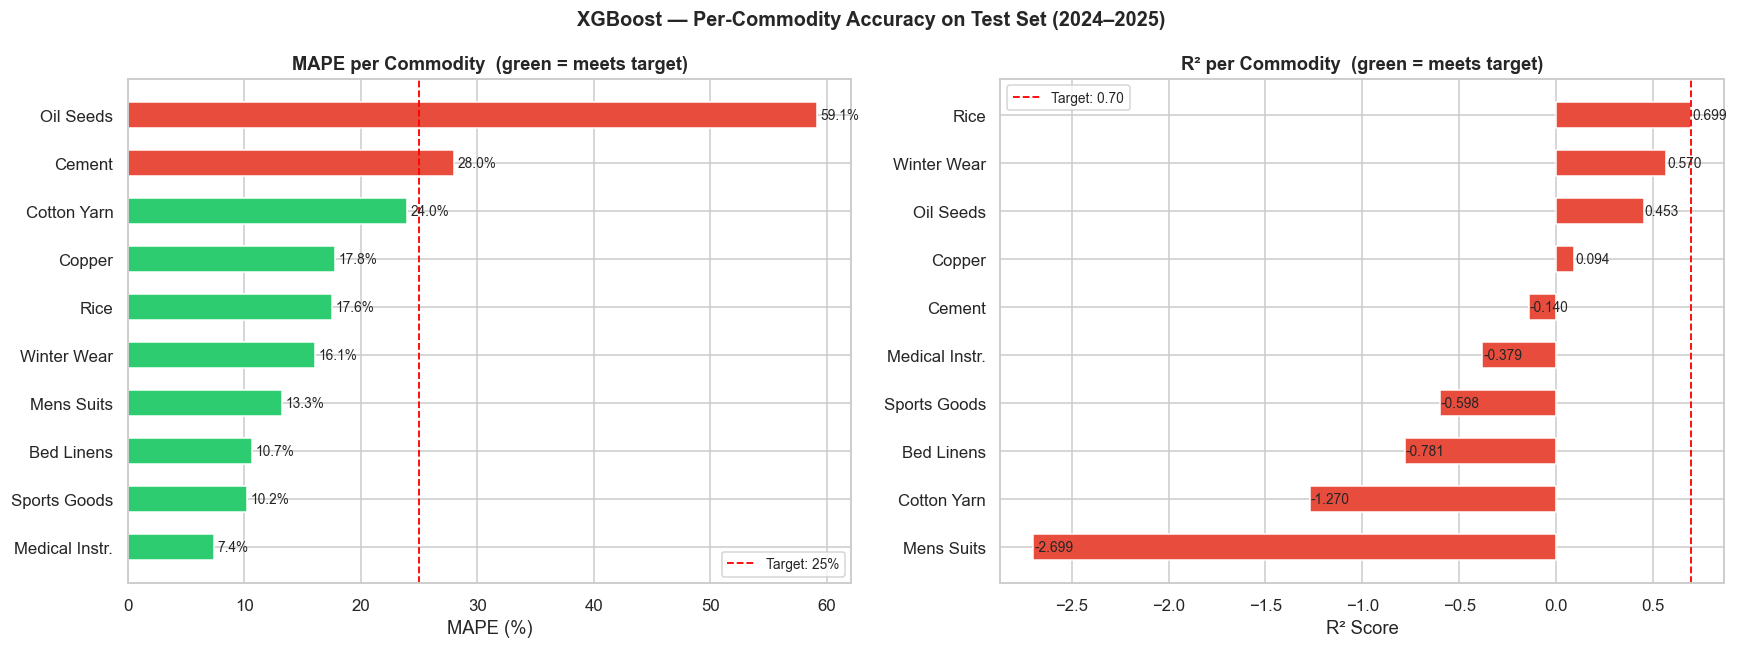

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MAPE per commodity
sorted_comm = comm_df.sort_values('MAPE_%', ascending=True)
bar_cols = ['#2ecc71' if v < 25 else '#e74c3c' for v in sorted_comm['MAPE_%'].values]
bars = axes[0].barh(sorted_comm['Commodity'], sorted_comm['MAPE_%'],
                    color=bar_cols, edgecolor='white', height=0.55)
axes[0].axvline(25, color='red', linestyle='--', linewidth=1.2, label='Target: 25%')
axes[0].set_xlabel('MAPE (%)')
axes[0].set_title('MAPE per Commodity  (green = meets target)', fontweight='bold')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, sorted_comm['MAPE_%'].values):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

# R² per commodity
sorted_r2 = comm_df.sort_values('R2', ascending=True)
bar_cols2 = ['#2ecc71' if v > 0.70 else '#e74c3c' for v in sorted_r2['R2'].values]
bars2 = axes[1].barh(sorted_r2['Commodity'], sorted_r2['R2'],
                     color=bar_cols2, edgecolor='white', height=0.55)
axes[1].axvline(0.70, color='red', linestyle='--', linewidth=1.2, label='Target: 0.70')
axes[1].set_xlabel('R² Score')
axes[1].set_title('R² per Commodity  (green = meets target)', fontweight='bold')
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, sorted_r2['R2'].values):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('XGBoost — Per-Commodity Accuracy on Test Set (2024–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 11 — Actual vs Predicted Plots (XGBoost Champion)

Visual check of forecast quality for each commodity over the 24-month test window (Jan 2024 – Dec 2025).  
A good model tracks the actual line closely — especially peaks and troughs.

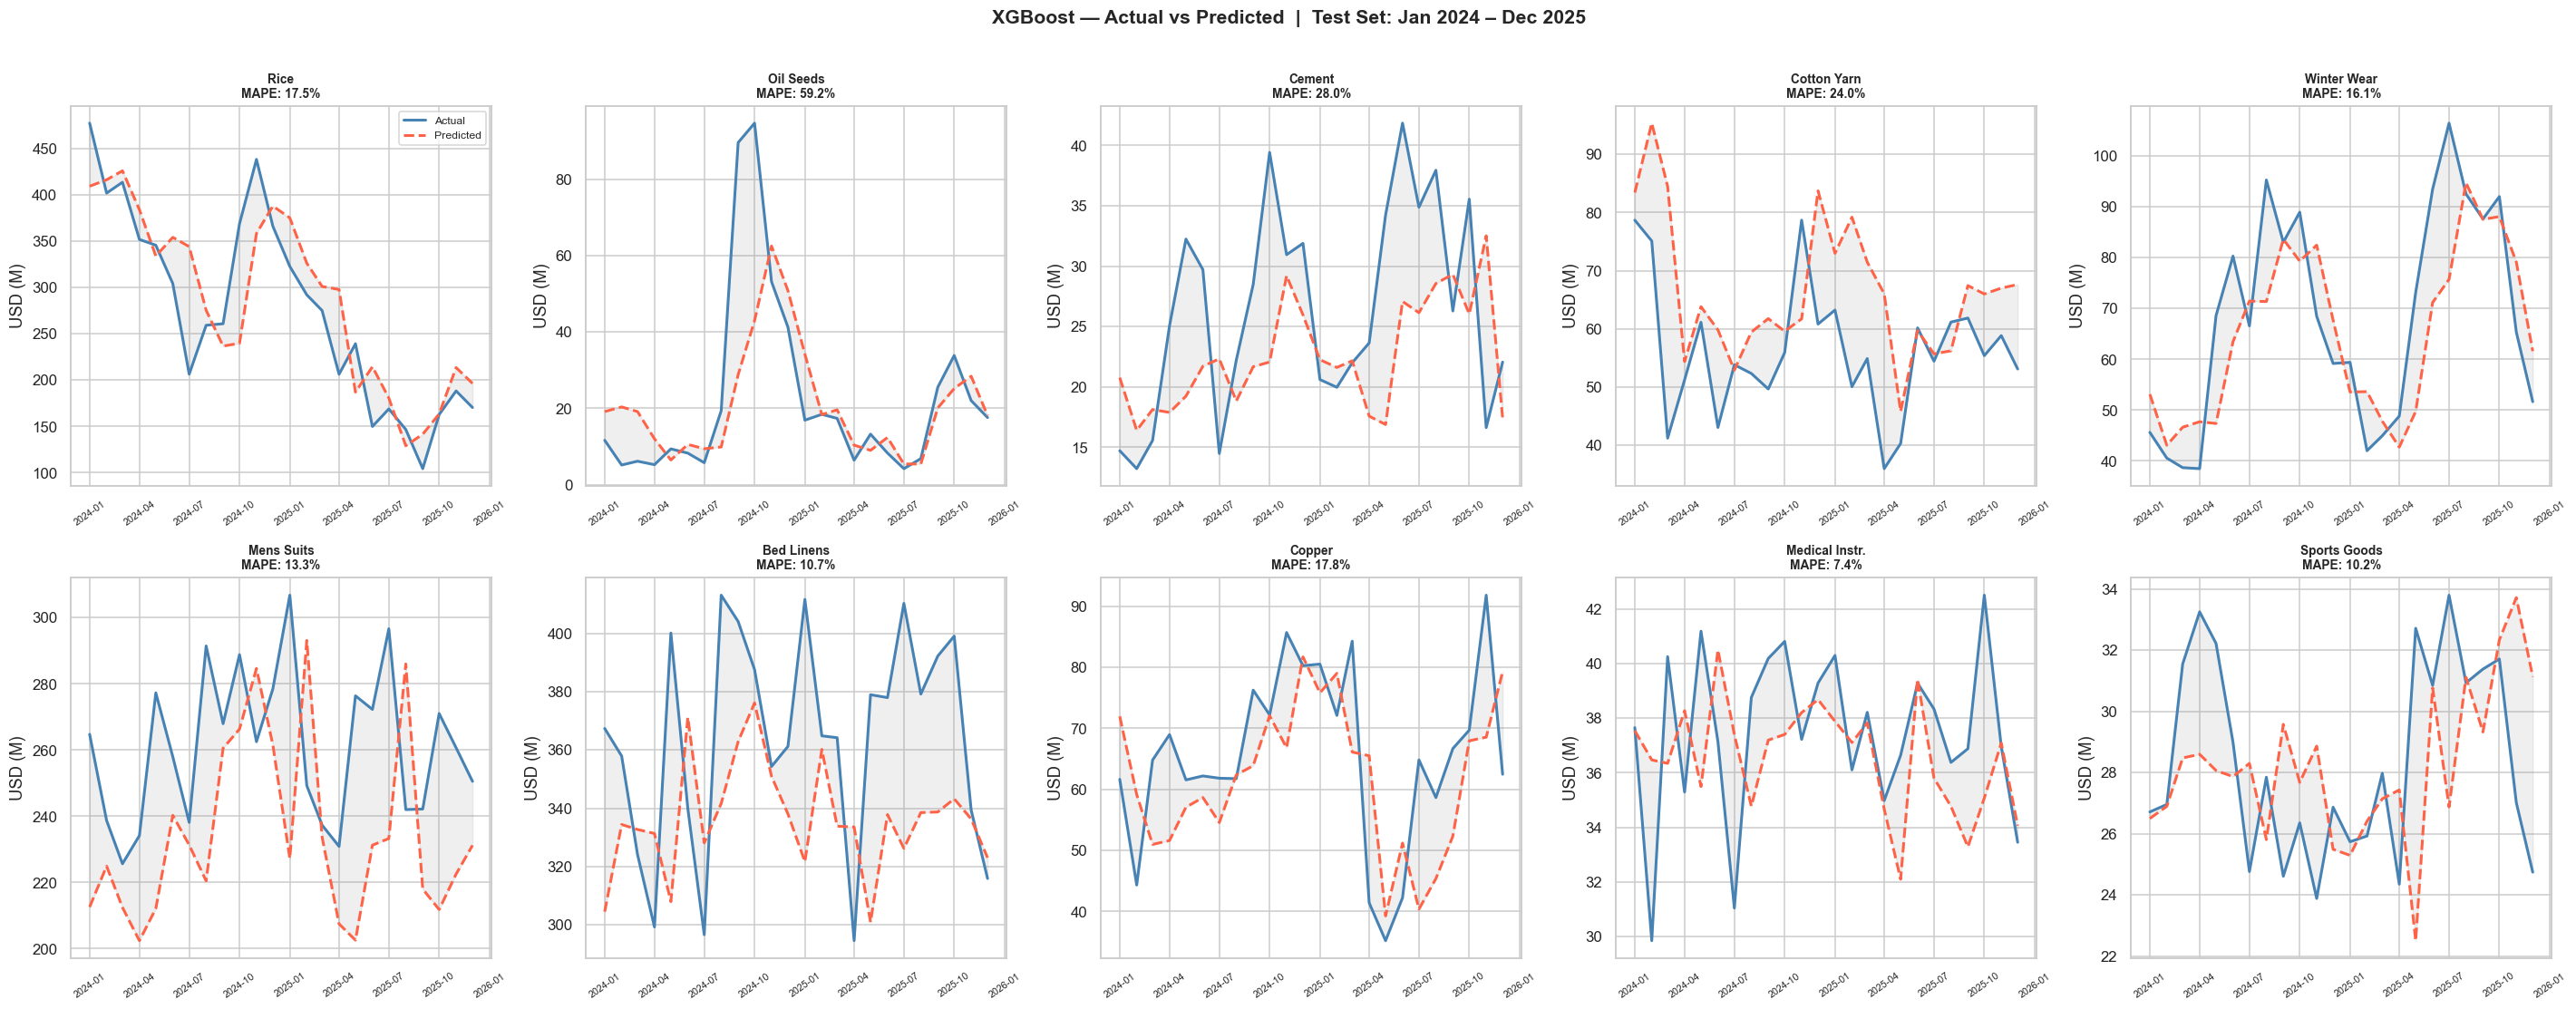

In [22]:
sorted_hs = sorted(test_df['HS_Code'].unique())

fig, axes = plt.subplots(2, 5, figsize=(26, 10), sharey=False)
axes = axes.flatten()

for i, hs in enumerate(sorted_hs):
    sub  = test_df[test_df['HS_Code'] == hs].sort_values('Date')
    mape = comm_mapes[hs]

    axes[i].plot(sub['Date'], sub['y_true'] / 1e6,
                 label='Actual', color='steelblue', linewidth=2)
    axes[i].plot(sub['Date'], sub['y_pred'] / 1e6,
                 label='Predicted', color='tomato', linewidth=2, linestyle='--')
    axes[i].fill_between(sub['Date'],
                         sub['y_true'] / 1e6, sub['y_pred'] / 1e6,
                         alpha=0.12, color='gray')
    axes[i].set_title(f'{HS_LABELS[hs]}\nMAPE: {mape:.1f}%',
                      fontsize=9, fontweight='bold')
    axes[i].set_ylabel('USD (M)')
    axes[i].tick_params(axis='x', rotation=35, labelsize=7)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('XGBoost — Actual vs Predicted  |  Test Set: Jan 2024 – Dec 2025',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

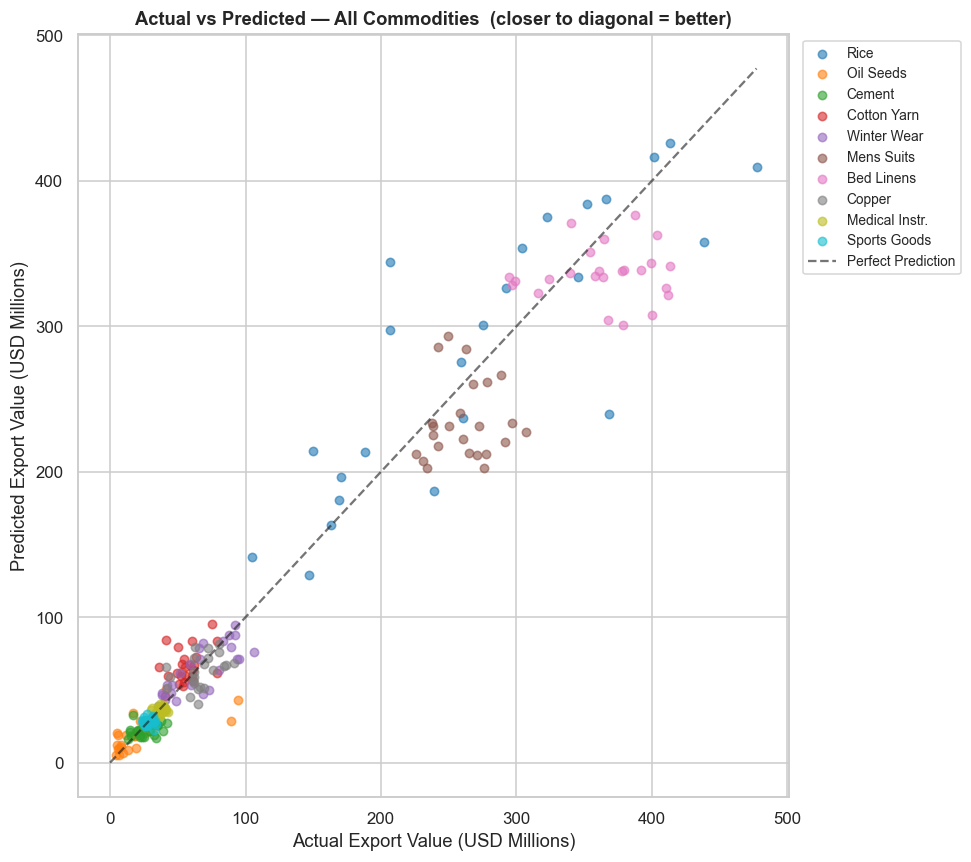

In [23]:
# Scatter plot: Actual vs Predicted for all commodities
# Points on the diagonal line = perfect prediction
fig, ax = plt.subplots(figsize=(9, 8))

for i, hs in enumerate(sorted_hs):
    sub = test_df[test_df['HS_Code'] == hs]
    ax.scatter(sub['y_true'] / 1e6, sub['y_pred'] / 1e6,
               alpha=0.6, s=30, color=COLORS[i], label=HS_LABELS[hs])

# Perfect prediction line
max_val = test_df[['y_true', 'y_pred']].max().max() / 1e6
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.5, alpha=0.6, label='Perfect Prediction')

ax.set_xlabel('Actual Export Value (USD Millions)')
ax.set_ylabel('Predicted Export Value (USD Millions)')
ax.set_title('Actual vs Predicted — All Commodities  (closer to diagonal = better)',
             fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 12 — Save Champion Model (XGBoost)

XGBoost achieved the lowest MAPE (20.41%) on the test set and is saved as the champion.  
The artifact is saved using `joblib` and contains everything Notebook 4 (Inference) needs — no retraining required.

In [24]:
MODELS_DIR = Path('..') / 'Models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / 'xgboost_champion.pkl'

# Save: model, feature list, and category order — everything Notebook 4 needs
model_artifact = {
    'model'         : xgb_model,
    'feature_cols'  : FEATURE_COLS,
    'hs_categories' : hs_categories,
    'hs_labels'     : HS_LABELS,
    'train_cutoff'  : 202312,
    'test_mape'     : results_df.loc[results_df['Model'] == 'XGBoost', 'MAPE_%'].values[0],
    'test_r2'       : results_df.loc[results_df['Model'] == 'XGBoost', 'R2'].values[0],
}

joblib.dump(model_artifact, MODEL_PATH)

file_size_kb = MODEL_PATH.stat().st_size / 1024
print('Champion model saved successfully.')
print(f'Path      : {MODEL_PATH.resolve()}')
print(f'File size : {file_size_kb:.1f} KB')
print()
print('Artifact contents:')
for key in model_artifact:
    print(f'  {key}')

Champion model saved successfully.
Path      : C:\Users\Talha Abbasi\Desktop\PECDF\Models\xgboost_champion.pkl
File size : 1854.1 KB

Artifact contents:
  model
  feature_cols
  hs_categories
  hs_labels
  train_cutoff
  test_mape
  test_r2


---
## Summary

### What Was Accomplished
- Trained **4 models** on panel data (1,620 train rows, 240 test rows)
- Evaluated each using MAPE, RMSE, and R² on the unseen 2024–2025 test set
- Selected **XGBoost** as champion — lowest MAPE (20.41%), R² of 0.9482
- Analysed per-commodity accuracy — identified which commodities the model handles best
- Saved the complete model artifact to `Models/xgboost_champion.pkl`

### Key Findings
- **Lag features** (`Lag_1M`, `Lag_3M`, `Lag_6M`) are the most important predictors — confirming the EDA finding
- **Oil Seeds** shows the highest MAPE (>100%) — extreme volatility makes it inherently hard to predict
- **Textile commodities** (Bed Linens, Mens Suits) show the lowest MAPE — strong momentum patterns
- XGBoost outperformed LightGBM on this dataset (20.41% vs 28.02% MAPE)

### Next Step → Notebook 4: Inference
Load the `.pkl` file, feed it a hypothetical row of future data, and generate a prediction.  
This notebook acts as the exact blueprint for the FastAPI backend.